[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


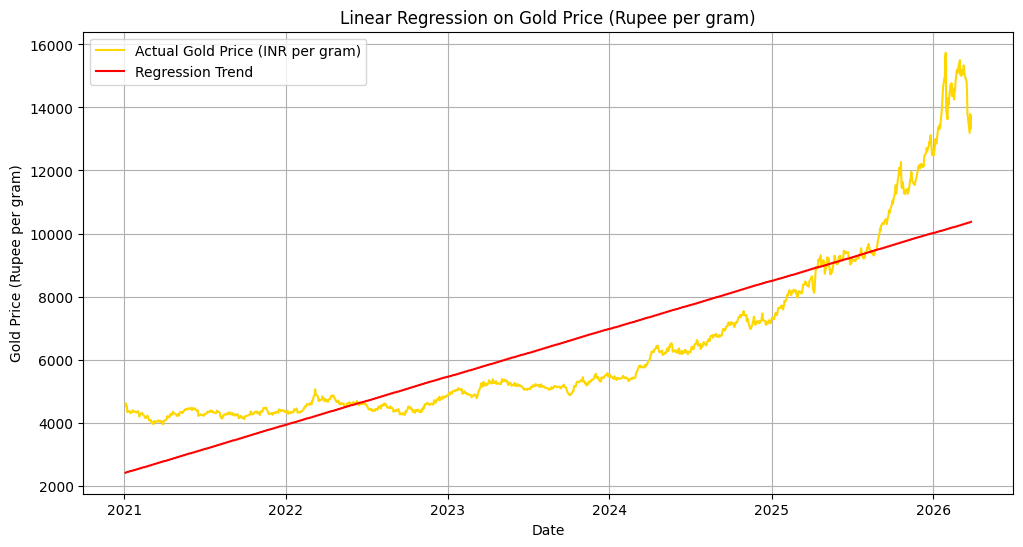

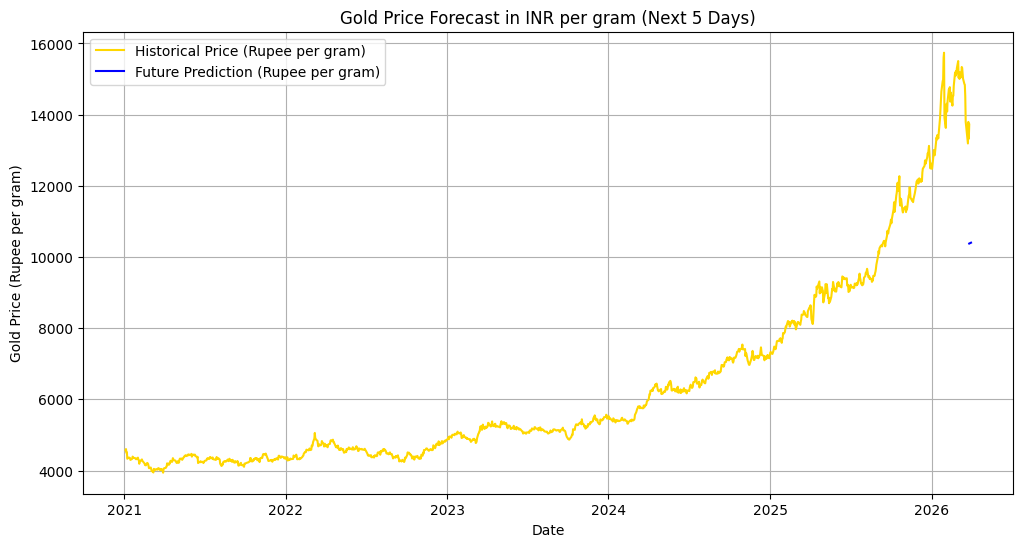

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import yfinance as yf

import warnings
warnings.filterwarnings("ignore")

# Download data
gold = yf.download("GC=F", start="2021-01-01")
fx = yf.download("USDINR=X", start="2021-01-01")

# Flatten MultiIndex columns
gold.columns = gold.columns.get_level_values(0)
fx.columns = fx.columns.get_level_values(0)

# Keep only Close prices
gold = gold[['Close']].rename(columns={'Close': 'Gold_USD'}).dropna()
fx = fx[['Close']].rename(columns={'Close': 'USDINR'}).dropna()

# now gold and inr in one table
df = gold.join(fx, how='inner')

df['Gold_INR'] = df['Gold_USD'] * df['USDINR']
df['Gold_INR_per_gram'] = df['Gold_INR'] / 31.1034768

# Time index
df['t'] = np.arange(len(df))

X = df[['t']]
y = df['Gold_INR_per_gram']   # ⭐ Train on per‑gram price

# Train Linear Regression Model
model = LinearRegression()
model.fit(X, y)

df['Predicted_INR_per_gram'] = model.predict(X)

# Plot actual vs predicted (per gram)
plt.figure(figsize=(12,6))
plt.plot(df.index, df['Gold_INR_per_gram'], label="Actual Gold Price (INR per gram)", color="gold")
plt.plot(df.index, df['Predicted_INR_per_gram'], label="Regression Trend", color="red")

plt.title("Linear Regression on Gold Price (Rupee per gram)")
plt.xlabel("Date")
plt.ylabel("Gold Price (Rupee per gram)")
plt.legend()
plt.grid(True)
plt.show()

# Predict Next 30 Days (per gram)
future_days = 5
future_t = np.arange(len(df), len(df) + future_days).reshape(-1, 1)
future_pred = model.predict(future_t)
future_dates = pd.date_range(start=df.index[-1], periods=future_days, freq='D')

plt.figure(figsize=(12,6))
plt.plot(df.index, df['Gold_INR_per_gram'], label="Historical Price (Rupee per gram)", color="gold")
plt.plot(future_dates, future_pred, label="Future Prediction (Rupee per gram)", color="blue")

plt.title(f"Gold Price Forecast in INR per gram (Next {future_days} Days)")
plt.xlabel("Date")
plt.ylabel("Gold Price (Rupee per gram)")
plt.legend()
plt.grid(True)
plt.show()